# **Feature engineering**

[Загрузка данных](#Loading-data)

- [age](#age)
- [MonthlyIncome](#MonthlyIncome)
- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [DebtRatio](#DebtRatio)
- [NumberOfDependents](#NumberOfDependents)
- [NumberOfOpenCreditLinesAndLoans](#NumberOfOpenCreditLinesAndLoans)
- [NumberRealEstateLoansOrLines](#NumberRealEstateLoansOrLines)
- [NumberOfTime30-59DaysPastDueNotWorse](#NumberOfTime30-59DaysPastDueNotWorse)
- [NumberOfTime60-89DaysPastDueNotWorse](#NumberOfTime60-89DaysPastDueNotWorse)
- [NumberOfTimes90DaysLate](#NumberOfTimes90DaysLate)

[Результирующие признаки](#Resulting-DataFrames)

---

## Loading data

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

import random
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from optbinning import OptimalBinning

from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import scale, robust_scale, power_transform

from src import *

set_seeds()
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
train_raw = pd.read_csv('../data/raw/cs-training.csv').drop(columns=['Unnamed: 0'])
print(f"Data shape: {train_raw.shape}")

X = train_raw.drop(columns=['SeriousDlqin2yrs']).copy()
y = train_raw['SeriousDlqin2yrs'].copy()
print(f"Data shape: {train_raw.shape}")

X = train_raw.drop(columns=['SeriousDlqin2yrs']).copy()
y = train_raw['SeriousDlqin2yrs'].copy()

Data shape: (150000, 11)
Data shape: (150000, 11)


In [3]:
# DataFrames for WoE and non-WoE preprocessed features

train_woe       = train_raw.copy()
train_processed = train_raw.copy()

---

## `age`

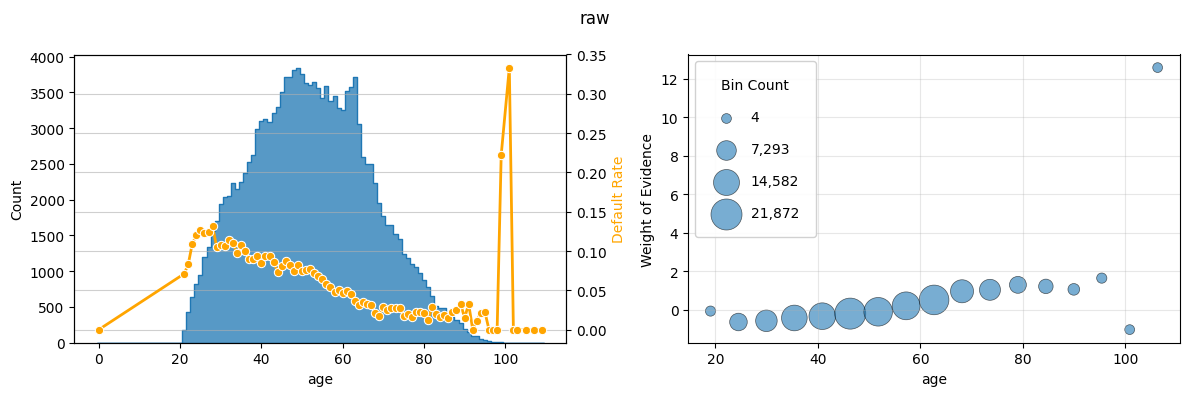

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'age',
                      n_quantiles=40, discrete=True, title='', ax=axs[0])
plot_WoE(train_raw, 'age', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

In [5]:
AGE_CLIP_UPPER_PCTL = 0.99

AGE_CLIP_UPPER = train_raw.age.quantile(AGE_CLIP_UPPER_PCTL)
AGE_CLIP_LOWER = 21

print(f'{AGE_CLIP_UPPER_PCTL * 100} процентиль: {AGE_CLIP_UPPER}')

99.0 процентиль: 87.0


### Preprocessing

In [6]:
train_processed['age'] = scale(train_raw['age'].clip(lower=AGE_CLIP_LOWER, upper=AGE_CLIP_UPPER))

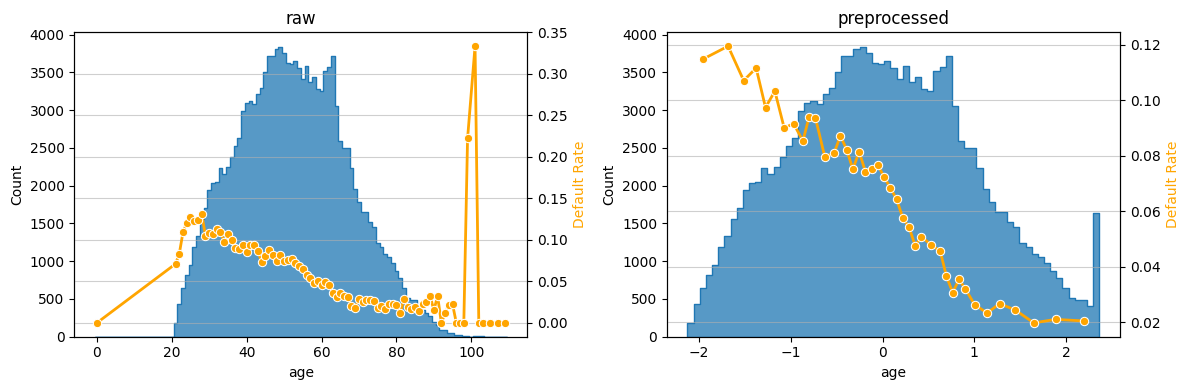

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'age',
                      title=rf'raw', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'age', y, bins=train_processed['age'].unique().size,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [8]:
YOUNG_THRESHOLD  = 30
SENIOR_THRESHOLD = 59

train_processed['is_young']  = train_raw['age'].lt(YOUNG_THRESHOLD).astype(int)
train_processed['is_senior'] = train_raw['age'].gt(SENIOR_THRESHOLD).astype(int)

train_processed['age^2'] = scale(train_raw['age'].clip(lower=AGE_CLIP_LOWER, upper=AGE_CLIP_UPPER) ** 2)
train_processed['age^3'] = scale(train_raw['age'].clip(lower=AGE_CLIP_LOWER, upper=AGE_CLIP_UPPER) ** 3)

In [9]:
age_new_features = ['is_young', 'is_senior', 'age^2', 'age^3']
train_processed[age_new_features].describe(percentiles=[])

,is_young,is_senior,age^2,age^3
count,150000.000000,150000.00000,1.500000e+05,1.500000e+05
mean,0.058807,0.32212,-8.337035e-17,-7.958079e-18
std,0.235263,0.46729,1.000003e+00,1.000003e+00
min,0.000000,0.00000,-1.575598e+00,-1.200172e+00
max,1.000000,1.00000,2.904846e+00,3.441374e+00


### WoE Transformation

In [10]:
train_woe['age'], age_binner = apply_woe_binning(
    df=train_raw,
    feature='age',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    monotonic_trend='descending'
)

Feature: age
Binning status: OPTIMAL, N bins: 9
Bins: [29.5 36.5 43.5 52.5 55.5 59.5 62.5 67.5 74.5]



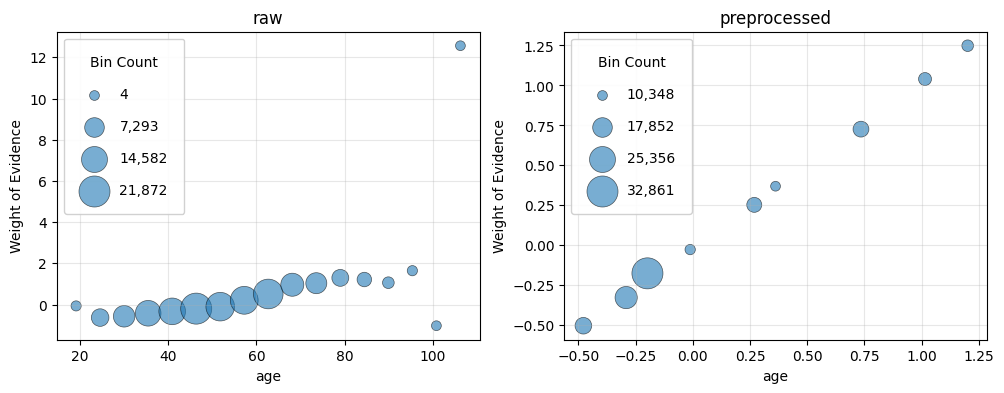

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_WoE(train_raw, 'age', 'SeriousDlqin2yrs', ax=axs[0], title='raw',
         xlabel='age');

plot_WoE(train_woe, 'age', 'SeriousDlqin2yrs', ax=axs[1],
         title='preprocessed', xlabel='age');

In [12]:
binning_table = age_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 29.50)",8821,0.058807,7786,1035,0.117334,-0.618349,0.029438,0.003622
1,"[29.50, 36.50)",15044,0.100293,13451,1593,0.105889,-0.502841,0.031574,0.003906
2,"[36.50, 43.50)",20644,0.137627,18779,1865,0.090341,-0.326797,0.016946,0.002109
3,"[43.50, 52.50)",32861,0.219073,30277,2584,0.078634,-0.175225,0.007259,0.000906
4,"[52.50, 55.50)",10625,0.070833,9897,728,0.068518,-0.026589,0.000051,0.000006
5,"[55.50, 59.50)",13687,0.091247,12966,721,0.052678,0.253172,0.005245,0.000654
6,"[59.50, 62.50)",10348,0.068987,9860,488,0.047159,0.369651,0.008047,0.001000
7,"[62.50, 67.50)",14368,0.095787,13887,481,0.033477,0.726566,0.037226,0.004554
8,"[67.50, 74.50)",12232,0.081547,11930,302,0.024689,1.04011,0.057319,0.006858
9,"[74.50, inf)",11370,0.075800,11141,229,0.020141,1.24839,0.070850,0.008322


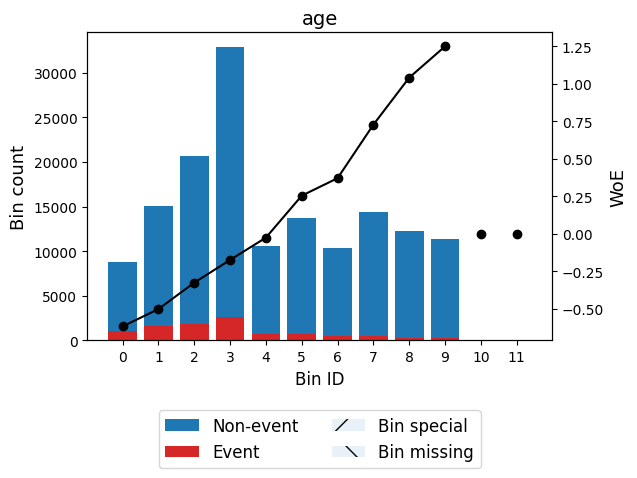

In [13]:
binning_table.plot(figsize=(6, 4))

## `MonthlyIncome`

In [14]:
INCOME_CLIP_UPPER_PCTL      = 0.90
INCOME_THRESHOLD_LOWER_PCTL = 0.10

INCOME_CLIP_UPPER      = train_raw['MonthlyIncome'].quantile(INCOME_CLIP_UPPER_PCTL)
INCOME_THRESHOLD_LOWER = train_raw['MonthlyIncome'].quantile(INCOME_THRESHOLD_LOWER_PCTL)

print(f'Low  income threshold: {INCOME_THRESHOLD_LOWER:.2f}')
print(f'High income threshold: {INCOME_CLIP_UPPER:.2f}')

Low  income threshold: 2005.00
High income threshold: 11666.00


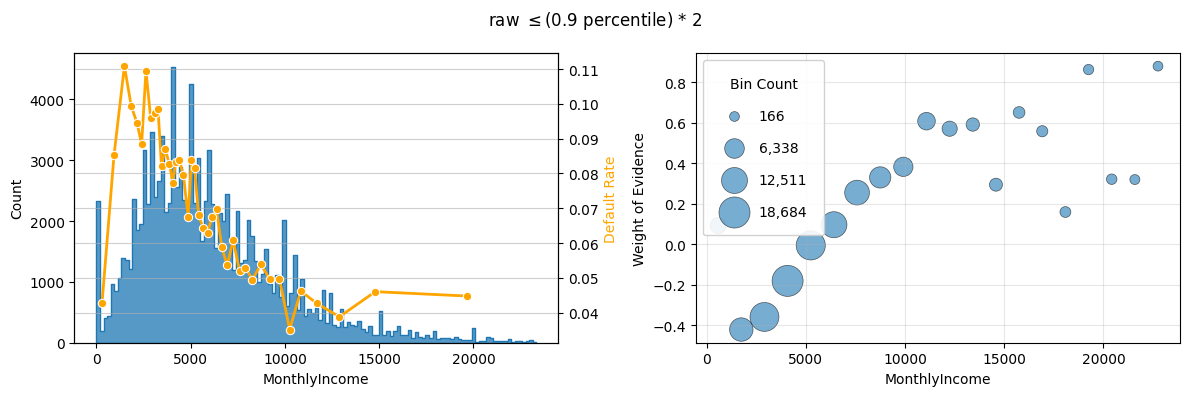

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'MonthlyIncome', max_value=INCOME_CLIP_UPPER*2,
                      n_quantiles=40, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.MonthlyIncome.le(INCOME_CLIP_UPPER*2)], 'MonthlyIncome', ax=axs[1])

fig.suptitle(fr'raw $\leq ({INCOME_CLIP_UPPER_PCTL}$ percentile) * 2')
plt.tight_layout()

### Preprocessing

In [16]:
train_processed['MonthlyIncome'] = scale(train_raw['MonthlyIncome'].fillna(0.0).clip(upper=INCOME_CLIP_UPPER)) # .where(train_raw['MonthlyIncome'].le(INCOME_CLIP_UPPER), 0.0))

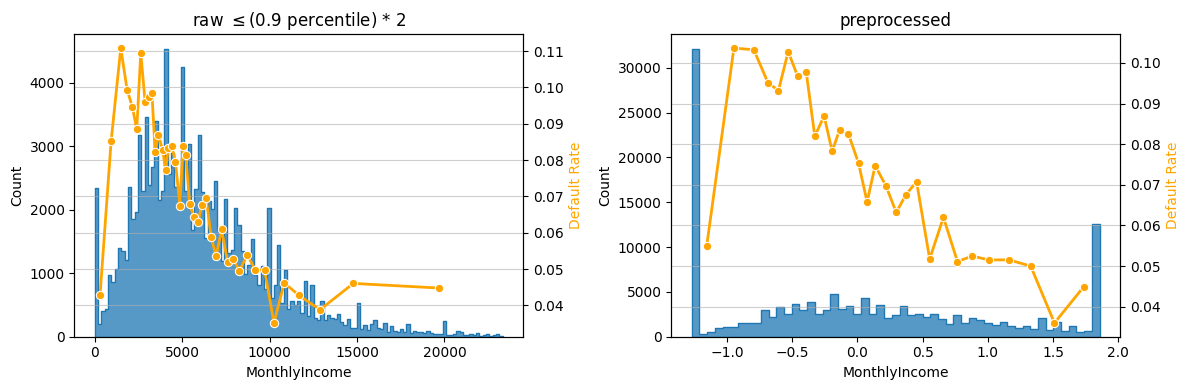

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'MonthlyIncome', max_value=INCOME_CLIP_UPPER*2,
                      title=rf'raw $\leq ({INCOME_CLIP_UPPER_PCTL}$ percentile) * 2', ax=axes[0])
plot_feature_analysis(train_processed, 'MonthlyIncome', y,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [18]:
train_processed['MonthlyIncome_missing'] = train_raw['MonthlyIncome'].isna().astype(int)
train_processed['MonthlyIncome_clipped'] = train_raw['MonthlyIncome'].gt(INCOME_CLIP_UPPER).astype(int)
train_processed['MonthlyIncome_zero']    = train_raw['MonthlyIncome'].eq(0.0).astype(int)

train_processed['LowIncome']  = train_raw['MonthlyIncome'].le(INCOME_THRESHOLD_LOWER).astype(int)

In [19]:
income_new_features = ['MonthlyIncome_missing', 'MonthlyIncome_zero', 'MonthlyIncome_clipped', 'LowIncome']
train_processed[income_new_features].describe(percentiles=[])

,MonthlyIncome_missing,MonthlyIncome_zero,MonthlyIncome_clipped,LowIncome
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.198207,0.010893,0.079400,0.080187
std,0.398650,0.103801,0.270363,0.271583
min,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


### WoE Transformation

In [20]:
train_woe['MonthlyIncome'] = train_raw['MonthlyIncome'].fillna(0.0)

In [21]:
train_woe['MonthlyIncome'], income_binner = apply_woe_binning(
    df=train_woe,
    feature='MonthlyIncome',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    monotonic_trend='auto'
)

Feature: MonthlyIncome
Binning status: OPTIMAL, N bins: 8
Bins: [ 930.5 2000.5 3332.5 4833.5 5330.5 6643.5 7656.5 9945.5]



In [22]:
binning_table = income_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 930.50)",34046,0.226973,32175,1871,0.054955,0.208442,9.014962e-03,1.124835e-03
1,"[930.50, 2000.50)",7688,0.051253,6876,812,0.105619,-0.499983,1.593247e-02,1.971070e-03
2,"[2000.50, 3332.50)",16898,0.112653,15240,1658,0.098118,-0.417963,2.361187e-02,2.930187e-03
3,"[3332.50, 4833.50)",22942,0.152947,21046,1896,0.082643,-0.229311,8.886214e-03,1.108349e-03
4,"[4833.50, 5330.50)",7542,0.050280,7007,535,0.070936,-0.063877,2.109189e-04,2.636038e-05
5,"[5330.50, 6643.50)",16066,0.107107,14992,1074,0.066849,-0.000148,2.353920e-09,2.942400e-10
6,"[6643.50, 7656.50)",9903,0.066020,9353,550,0.055539,0.197259,2.359650e-03,2.944790e-04
7,"[7656.50, 9945.50)",14975,0.099833,14207,768,0.051285,0.281425,7.006530e-03,8.729375e-04
8,"[9945.50, inf)",19940,0.132933,19078,862,0.043230,0.460761,2.318562e-02,2.872834e-03
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00


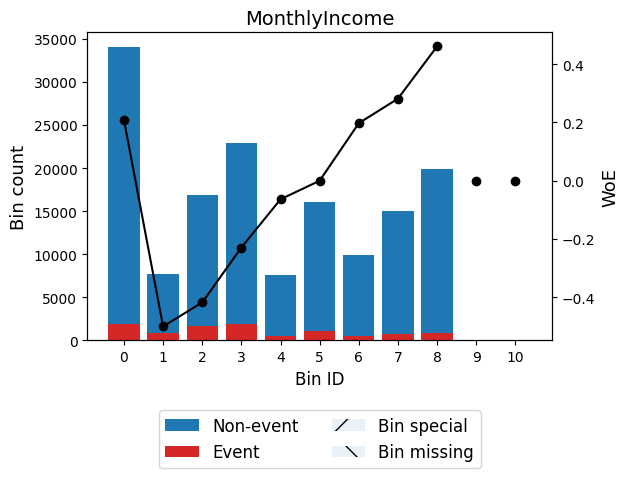

In [23]:
binning_table.plot(figsize=(6, 4))

## `RevolvingUtilizationOfUnsecuredLines`

In [24]:
UTIL_CLIP_UPPER_PCTL = 0.99

UTIL_CLIP_UPPER = train_raw['RevolvingUtilizationOfUnsecuredLines'].quantile(UTIL_CLIP_UPPER_PCTL)
print(f'{100*UTIL_CLIP_UPPER_PCTL} процентиль: {UTIL_CLIP_UPPER}')

UTIL_CLIP_UPPER = 1.0

99.0 процентиль: 1.0929557681400022


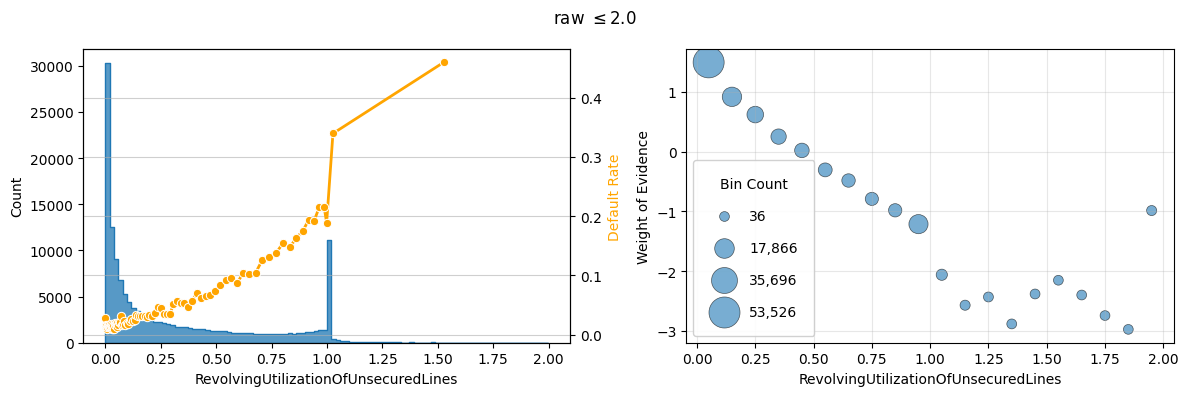

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'RevolvingUtilizationOfUnsecuredLines',
                      n_quantiles=100, max_value=UTIL_CLIP_UPPER*2, title='', ax=axs[0])
plot_WoE(train_raw, 'RevolvingUtilizationOfUnsecuredLines', clip_max=UTIL_CLIP_UPPER*2, ax=axs[1])

fig.suptitle(fr'raw $\leq {UTIL_CLIP_UPPER*2}$')
plt.tight_layout()

### Preprocessing

In [26]:
train_processed['RevolvingUtilizationOfUnsecuredLines'] = \
    scale(train_raw['RevolvingUtilizationOfUnsecuredLines'].clip(upper=UTIL_CLIP_UPPER))

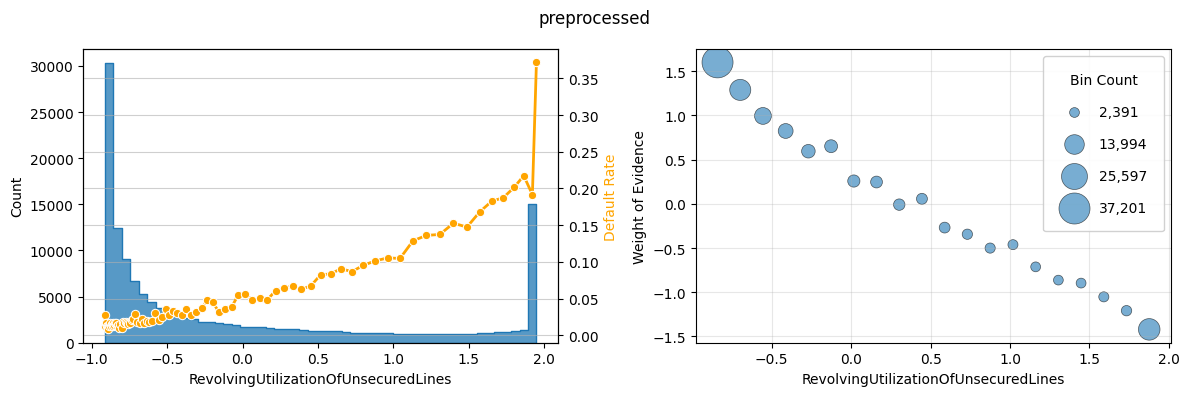

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_processed, 'RevolvingUtilizationOfUnsecuredLines',
                      n_quantiles=100, title='', ax=axs[0])
plot_WoE(train_processed, 'RevolvingUtilizationOfUnsecuredLines', ax=axs[1])

fig.suptitle('preprocessed')
plt.tight_layout()

### New Features

In [28]:
train_processed['utilization_clipped'] = \
    train_raw['RevolvingUtilizationOfUnsecuredLines'].gt(UTIL_CLIP_UPPER).astype(int)

train_processed['utilization_99999990'] = \
    train_raw['RevolvingUtilizationOfUnsecuredLines'].eq(0.9999999).astype(int)

In [29]:
util_new_features = ['utilization_clipped', 'utilization_99999990']
train_processed[util_new_features].describe(percentiles=[])

,utilization_clipped,utilization_99999990
count,150000.000000,150000.000000
mean,0.022140,0.068373
std,0.147139,0.252386
min,0.000000,0.000000
max,1.000000,1.000000


### WoE Transformation

In [30]:
train_woe['RevolvingUtilizationOfUnsecuredLines'], util_binner = apply_woe_binning(
    df=train_raw,
    feature='RevolvingUtilizationOfUnsecuredLines',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    monotonic_trend='ascending'
)

Feature: RevolvingUtilizationOfUnsecuredLines
Binning status: OPTIMAL, N bins: 8
Bins: [0.05938394 0.13183673 0.21776091 0.30089724 0.38952631 0.49497613
 0.69814232 0.90326244]



In [31]:
binning_table = util_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.06)",52081,0.347207,51173,908,0.017434,1.395448,0.383783,0.044424
1,"[0.06, 0.13)",18962,0.126413,18560,402,0.021200,1.196037,0.110634,0.013060
2,"[0.13, 0.22)",12911,0.086073,12509,402,0.031136,0.801477,0.039489,0.004808
3,"[0.22, 0.30)",9027,0.060180,8676,351,0.038883,0.571255,0.015409,0.001900
4,"[0.30, 0.39)",7769,0.051793,7364,405,0.052130,0.264197,0.003227,0.000402
5,"[0.39, 0.49)",7611,0.050740,7122,489,0.064249,0.042306,0.000089,0.000011
6,"[0.49, 0.70)",11599,0.077327,10499,1100,0.094836,-0.380305,0.013200,0.001640
7,"[0.70, 0.90)",10172,0.067813,8662,1510,0.148447,-0.889439,0.078916,0.009552
8,"[0.90, inf)",19868,0.132453,15409,4459,0.224431,-1.396248,0.467267,0.054083
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


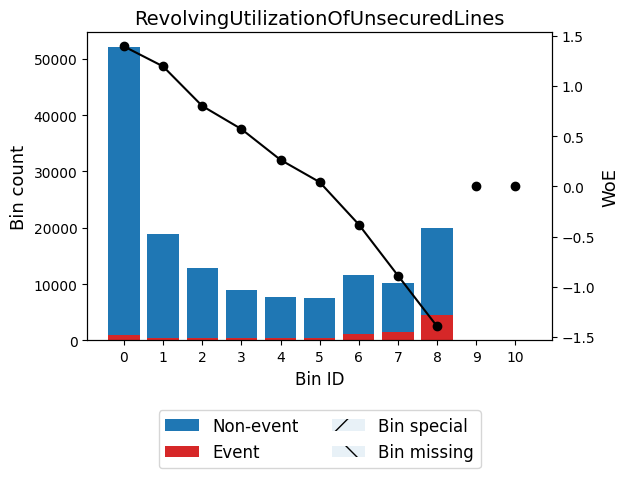

In [32]:
binning_table.plot(figsize=(6, 4))

## `DebtRatio`

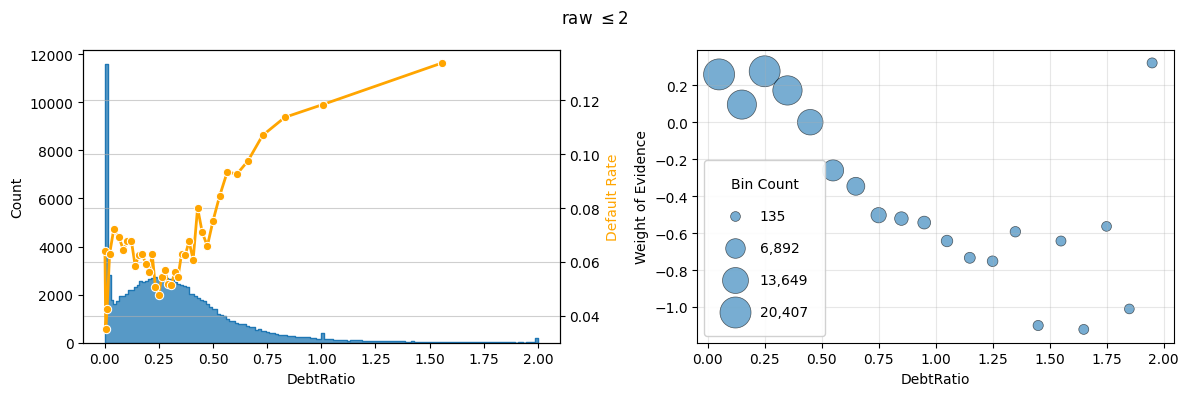

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DebtRatio',
                      max_value=2, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw.DebtRatio.le(2)], 'DebtRatio', ax=axs[1])

fig.suptitle(fr'raw $\leq 2$')
plt.tight_layout()
plt.show()

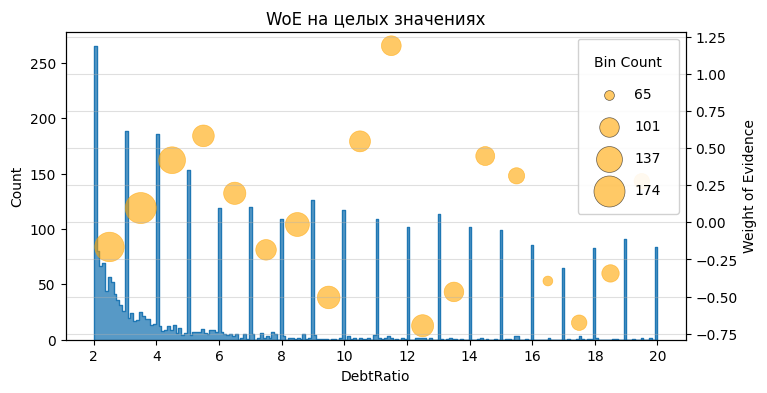

In [34]:
lower = 2
upper = 20

fig, ax1 = plt.subplots(figsize=(8, 4))

sns.histplot(
    x=train_raw.loc[train_raw.DebtRatio.between(left=lower, right=upper), 'DebtRatio'],
    element='step', 
    ax=ax1, 
    bins=200
)

test_whole = train_raw.loc[
    (train_raw.DebtRatio % 1 == 0) & 
    (train_raw.DebtRatio.between(lower, upper)),
    ['DebtRatio', 'SeriousDlqin2yrs']
].astype(int)

ax2 = ax1.twinx()
plot_WoE(
    test_whole, 
    'DebtRatio', 
    'SeriousDlqin2yrs', 
    edgecolors=None,
    ax=ax2, 
    bins=18, 
    color='orange', 
    title='WoE на целых значениях'
)

ax2.grid(True, alpha=0.4)
ax1.set_xticks(np.arange(lower, upper + 1, 2));

На целых значениях риск тоже немонотонен

### Preprocessing

Из-за природы фичи, имеет смысл попробовать её и без предобработки

In [35]:
DEBT_CLIP_UPPER = 2.0

In [36]:
custom_median = train_raw.loc[train_raw.DebtRatio.le(DEBT_CLIP_UPPER), 'DebtRatio'].median()
DebtRatio_clipped = train_raw[['DebtRatio']].where(train_raw.DebtRatio.le(DEBT_CLIP_UPPER),
                                              custom_median).clip(upper=DEBT_CLIP_UPPER)

train_processed['DebtRatio'] = power_transform(DebtRatio_clipped, method='yeo-johnson')

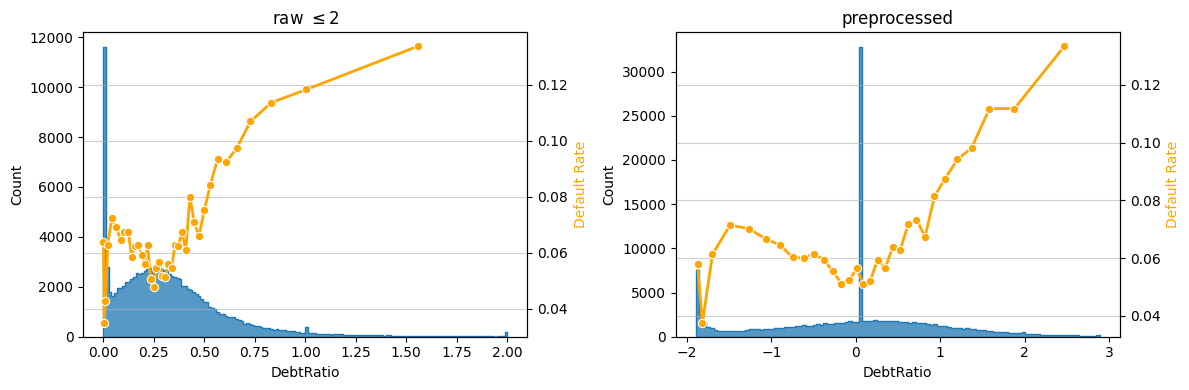

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'DebtRatio', max_value=2,
                      title=rf'raw $\leq {2}$', ax=axes[0])
plot_feature_analysis(train_processed, 'DebtRatio',
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [38]:
train_processed['DebtRatio^2'] = power_transform(DebtRatio_clipped ** 2, method='yeo-johnson')
train_processed['DebtRatio^3'] = power_transform(DebtRatio_clipped ** 3, method='yeo-johnson')

train_processed['DebtRatio_low'] = train_raw['DebtRatio'].lt(custom_median).astype(int)
train_processed['DebtRatio_clipped'] = train_raw['DebtRatio'].gt(DEBT_CLIP_UPPER).astype(int)

train_processed['DebtRatio_zero']  = train_raw['DebtRatio'].eq(0.0).astype(int)
train_processed['DebtRatio_whole'] = ((np.isclose(train_raw['DebtRatio'] % 1, 0, atol=1e-9)) &
                                      (train_raw['DebtRatio'].gt(0))).astype(int)

### WoE Transformation

In [39]:
train_woe['DebtRatio'], debt_binner = apply_woe_binning(
    df=train_raw,
    feature='DebtRatio',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=6,
    special_codes={'zero': 0},
)

Feature: DebtRatio
Binning status: OPTIMAL, N bins: 5
Bins: [  0.01634838   0.42332079   0.65367481   3.97284353 995.5       ]



In [40]:
binning_table = debt_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.02)",8296,0.055307,8009,287,0.034595,0.692564,0.019802,0.002427
1,"[0.02, 0.42)",71689,0.477927,67363,4326,0.060344,0.109178,0.005434,0.000679
2,"[0.42, 0.65)",21181,0.141207,19453,1728,0.081583,-0.215238,0.007184,0.000896
3,"[0.65, 3.97)",14652,0.097680,12965,1687,0.115138,-0.596973,0.045154,0.005562
4,"[3.97, 995.50)",13144,0.087627,12316,828,0.062995,0.063366,0.000342,0.000043
5,"[995.50, inf)",16925,0.112833,16095,830,0.049040,0.328563,0.010580,0.001317
6,zero,4113,0.027420,3773,340,0.082665,-0.229595,0.001597,0.000199
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.090094,0.011123


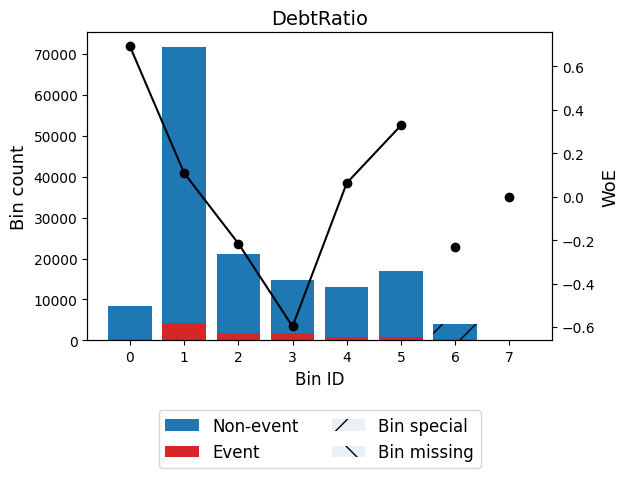

In [41]:
binning_table.plot(figsize=(6, 4))

## `NumberOfDependents`

In [42]:
DEPS_CLIP_UPPER_PCTL = 0.975
DEPS_CLIP_UPPER = train_raw.NumberOfDependents.quantile(DEPS_CLIP_UPPER_PCTL)

print(f'{100*DEPS_CLIP_UPPER_PCTL} процентиль: {DEPS_CLIP_UPPER}')

97.5 процентиль: 4.0


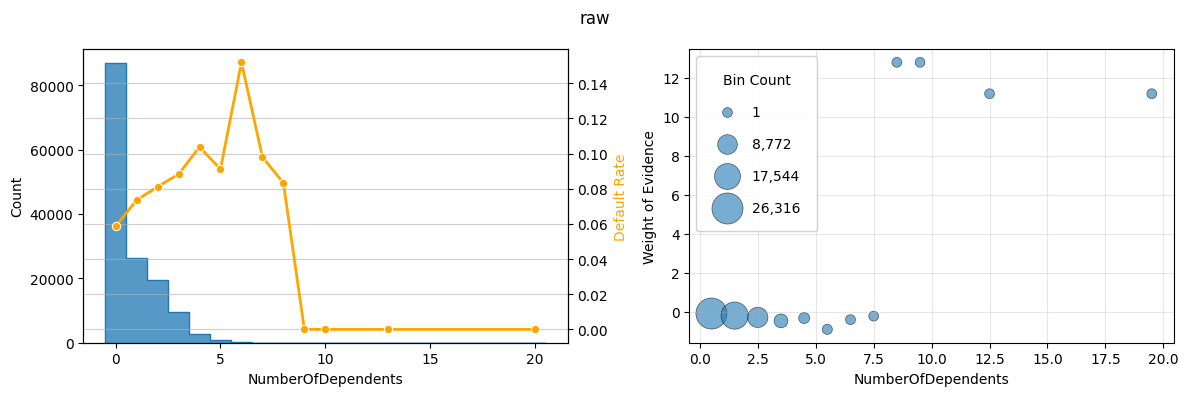

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfDependents', discrete=True,
                      title='', ax=axs[0])
plot_WoE(train_raw, 'NumberOfDependents', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### New Features

In [44]:
train_processed['NumberOfDependents_missing'] = train_raw['NumberOfDependents'].isna().astype(int)

### Preprocessing

In [45]:
train_processed['NumberOfDependents'] = scale(train_raw['NumberOfDependents'].fillna(0.0).clip(upper=DEPS_CLIP_UPPER))

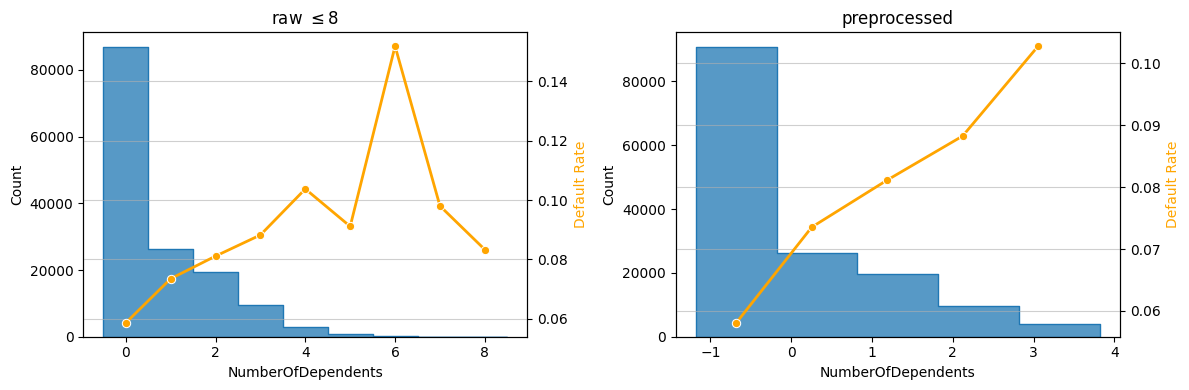

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfDependents', max_value=8,
                      title=rf'raw $\leq 8$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfDependents', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()
plt.show()

### WoE Transformation

In [47]:
train_woe['NumberOfDependents'], deps_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfDependents',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    min_prebin_size=0.02,
    monotonic_trend='ascending'
)

Feature: NumberOfDependents
Binning status: OPTIMAL, N bins: 4
Bins: [0.5 1.5 2.5 3.5]



In [48]:
binning_table = deps_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",86902,0.579347,81807,5095,0.058629,0.139828,0.010664,0.001332
1,"[0.50, 1.50)",26316,0.175440,24381,1935,0.073529,-0.102578,0.001930,0.000241
2,"[1.50, 2.50)",19522,0.130147,17938,1584,0.081139,-0.209307,0.006245,0.000779
3,"[2.50, 3.50)",9483,0.063220,8646,837,0.088263,-0.301247,0.006541,0.000815
4,"[3.50, inf)",3853,0.025687,3457,396,0.102777,-0.469533,0.006949,0.000861
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,3924,0.026160,3745,179,0.045617,0.404516,0.003601,0.000447
Totals,,150000,1.000000,139974,10026,0.066840,,0.035930,0.004475


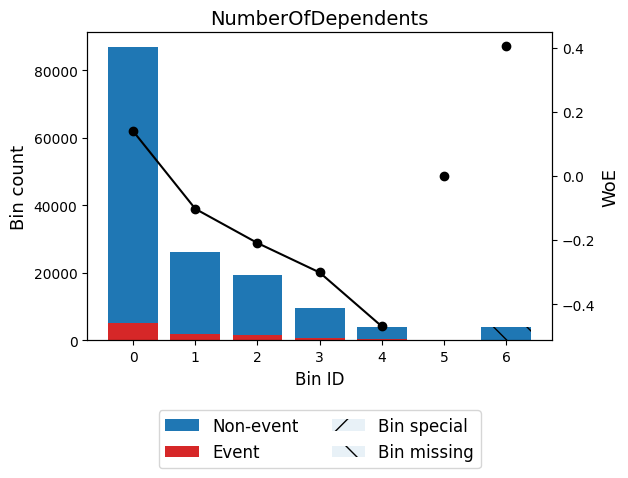

In [49]:
binning_table.plot(figsize=(6, 4))

## `NumberOfOpenCreditLinesAndLoans`

In [50]:
LOANS_CLIP_UPPER_PCTL = 0.99
LOANS_CLIP_UPPER = train_raw['NumberOfOpenCreditLinesAndLoans'].quantile(LOANS_CLIP_UPPER_PCTL)

print(f'{100*LOANS_CLIP_UPPER_PCTL} процентиль: {LOANS_CLIP_UPPER}')

99.0 процентиль: 24.0


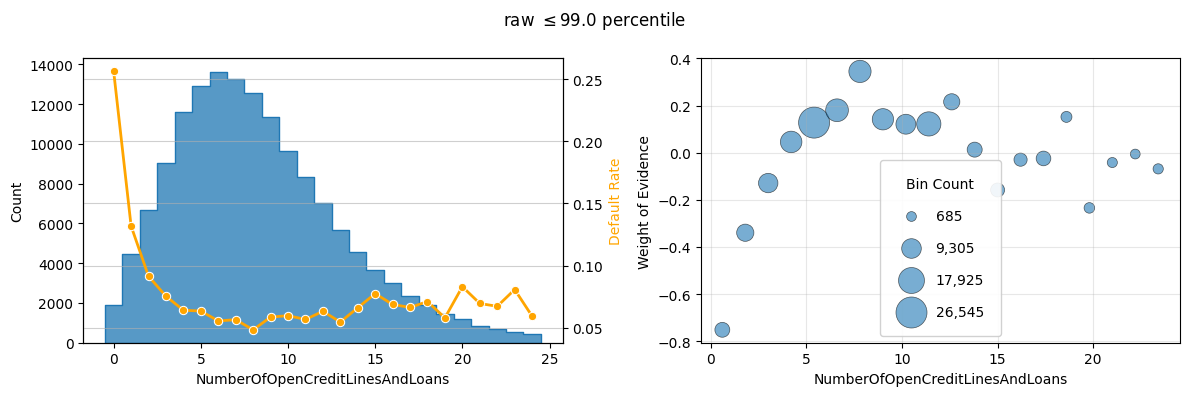

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfOpenCreditLinesAndLoans', discrete=True,
                      max_value=LOANS_CLIP_UPPER, title='', ax=axs[0])
plot_WoE(train_raw.loc[train_raw['NumberOfOpenCreditLinesAndLoans'].le(LOANS_CLIP_UPPER)], 'NumberOfOpenCreditLinesAndLoans', ax=axs[1])

fig.suptitle(fr'raw $\leq {100*LOANS_CLIP_UPPER_PCTL}$ percentile')
plt.tight_layout()

### Preprocessing

In [52]:
loans_clipped = train_raw['NumberOfOpenCreditLinesAndLoans'].clip(upper=LOANS_CLIP_UPPER)

train_processed['NumberOfOpenCreditLinesAndLoans'] = scale(np.log1p(loans_clipped))

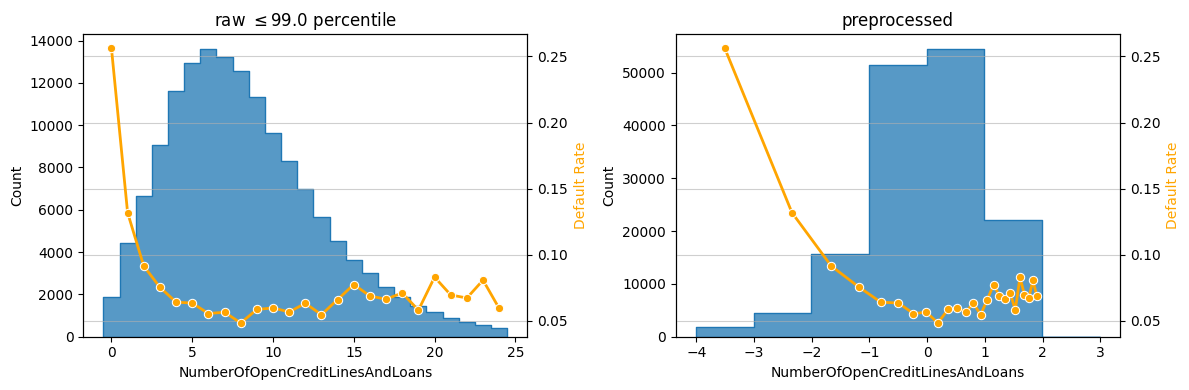

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfOpenCreditLinesAndLoans', max_value=LOANS_CLIP_UPPER,
                      title=fr'raw $\leq {100*LOANS_CLIP_UPPER_PCTL}$ percentile', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfOpenCreditLinesAndLoans', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [54]:
train_processed['NumberOfOpenCreditLinesAndLoans^2'] = scale(np.log1p(loans_clipped ** 2))
train_processed['NumberOfOpenCreditLinesAndLoans^3'] = scale(np.log1p(loans_clipped ** 3))

### WoE Transformation

In [55]:
train_woe['NumberOfOpenCreditLinesAndLoans'], loans_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfOpenCreditLinesAndLoans',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    monotonic_trend='descending'
)

Feature: NumberOfOpenCreditLinesAndLoans
Binning status: OPTIMAL, N bins: 4
Bins: [2.5 3.5 4.5 5.5]



In [56]:
binning_table = loans_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",12992,0.086613,11314,1678,0.129156,-0.727837,0.062984,0.007704
1,"[2.50, 3.50)",9058,0.060387,8376,682,0.075293,-0.128179,0.001049,0.000131
2,"[3.50, 4.50)",11609,0.077393,10866,743,0.064002,0.046423,0.000163,0.000020
3,"[4.50, 5.50)",12931,0.086207,12112,819,0.063336,0.057593,0.000279,0.000035
4,"[5.50, inf)",103410,0.689400,97306,6104,0.059027,0.132641,0.011454,0.001431
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.075929,0.009321


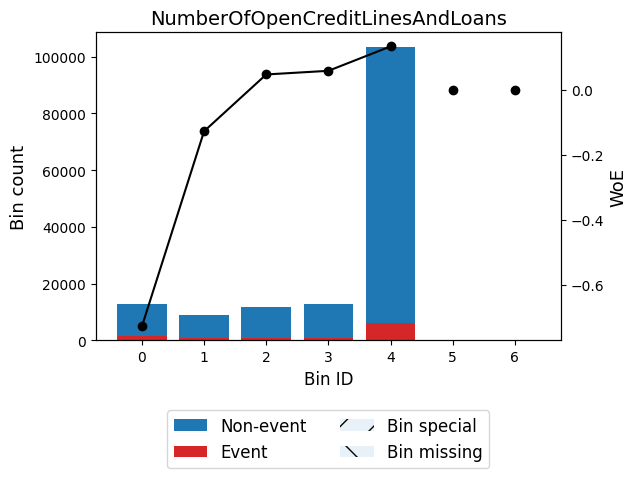

In [57]:
binning_table.plot(figsize=(6, 4))

## `NumberRealEstateLoansOrLines`

In [58]:
ESTATE_CLIP_UPPER_PCTL = 0.99
ESTATE_CLIP_UPPER = train_raw['NumberRealEstateLoansOrLines'].quantile(ESTATE_CLIP_UPPER_PCTL)

print(f'{100*ESTATE_CLIP_UPPER_PCTL} процентиль: {ESTATE_CLIP_UPPER}')

99.0 процентиль: 4.0


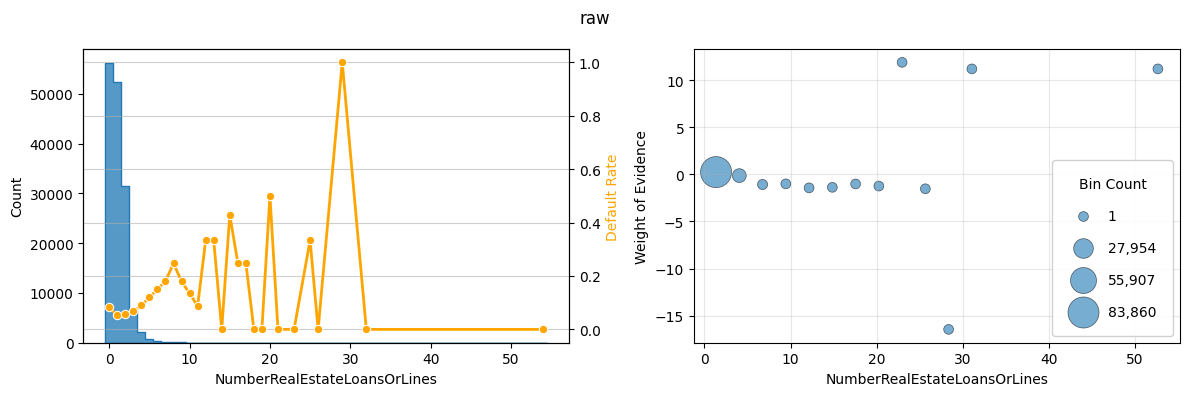

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberRealEstateLoansOrLines', discrete=True,
                      title='', ax=axs[0])
plot_WoE(train_raw, 'NumberRealEstateLoansOrLines', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### Preprocessing

In [60]:
estate_clipped = train_raw['NumberRealEstateLoansOrLines'].clip(upper=ESTATE_CLIP_UPPER)

train_processed['NumberRealEstateLoansOrLines'] = scale(estate_clipped)

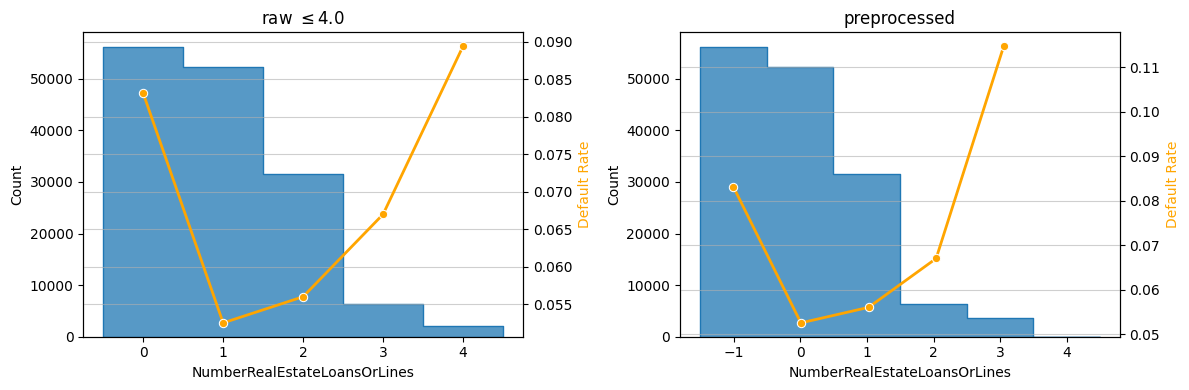

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberRealEstateLoansOrLines', max_value=ESTATE_CLIP_UPPER,
                      title=rf'raw $\leq {ESTATE_CLIP_UPPER}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberRealEstateLoansOrLines', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [62]:
train_processed['NumberRealEstateLoansOrLines^2'] = scale(estate_clipped ** 2)
train_processed['NumberRealEstateLoansOrLines^3'] = scale(estate_clipped ** 3)

### WoE Transformation

In [63]:
train_woe['NumberRealEstateLoansOrLines'], estate_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberRealEstateLoansOrLines',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    monotonic_trend='auto'
)

Feature: NumberRealEstateLoansOrLines
Binning status: OPTIMAL, N bins: 3
Bins: [0.5 1.5 2.5]



In [64]:
binning_table = estate_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",56188,0.374587,51516,4672,0.083149,-0.23597,0.023113,0.002882
1,"[0.50, 1.50)",52338,0.348920,49590,2748,0.052505,0.256641,0.020581,0.002566
2,"[1.50, 2.50)",31522,0.210147,29757,1765,0.055993,0.188639,0.006894,0.000861
3,"[2.50, inf)",9952,0.066347,9111,841,0.084506,-0.253629,0.004766,0.000594
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.055354,0.006903


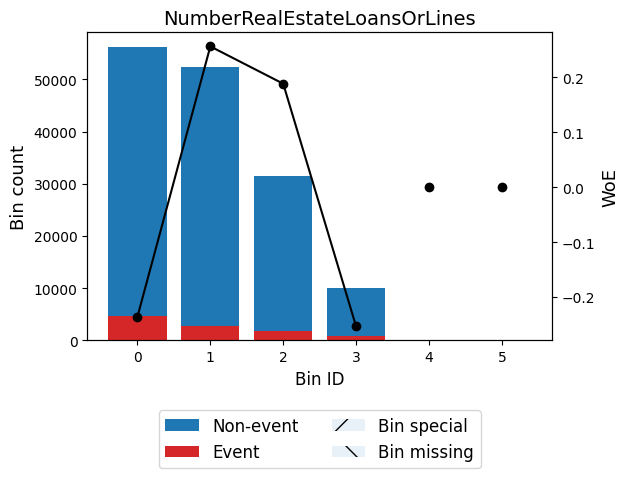

In [65]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTime30-59DaysPastDueNotWorse`

In [66]:
PD30_59_CLIP_UPPER_PCTL = 0.99
PD30_59_CLIP_UPPER = train_raw['NumberOfTime30-59DaysPastDueNotWorse'].quantile(PD30_59_CLIP_UPPER_PCTL)

print(f'{100*PD30_59_CLIP_UPPER_PCTL} процентиль: {PD30_59_CLIP_UPPER}')

99.0 процентиль: 4.0


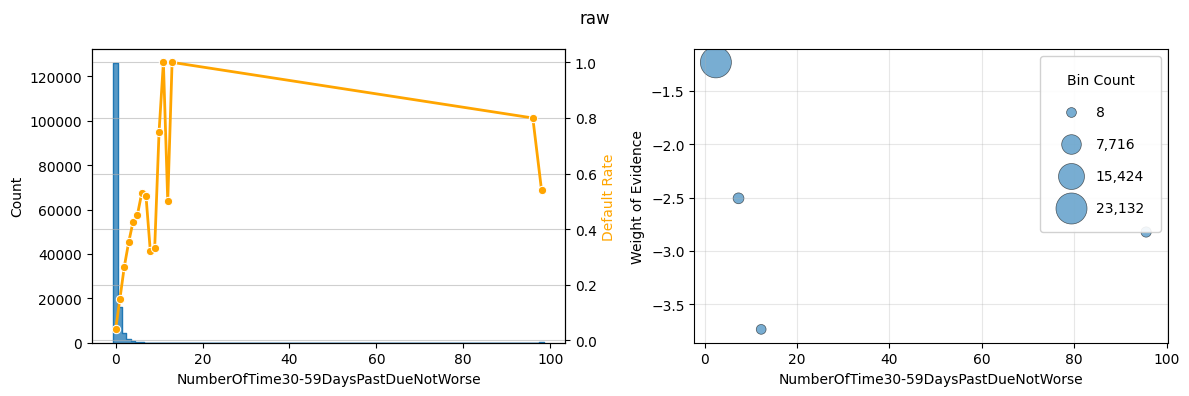

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime30-59DaysPastDueNotWorse', discrete=True,
                      title='', ax=axs[0])
plot_WoE(train_raw,
         'NumberOfTime30-59DaysPastDueNotWorse', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### Preprocessing

In [68]:
train_processed['NumberOfTime30-59DaysPastDueNotWorse'] = \
    scale(train_raw['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=PD30_59_CLIP_UPPER))

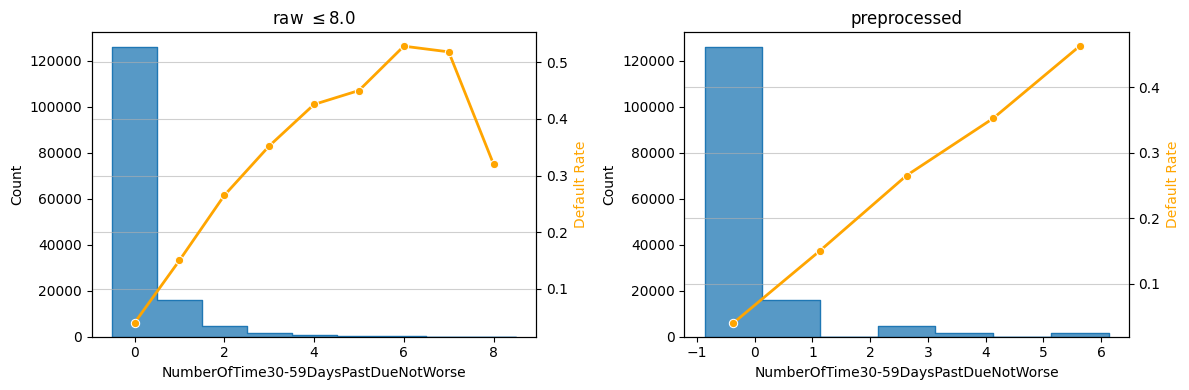

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime30-59DaysPastDueNotWorse', max_value=PD30_59_CLIP_UPPER*2,
                      title=rf'raw $\leq {PD30_59_CLIP_UPPER*2}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTime30-59DaysPastDueNotWorse', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### WoE Transformation

In [70]:
train_woe['NumberOfTime30-59DaysPastDueNotWorse'], pd30_59_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTime30-59DaysPastDueNotWorse',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    min_prebin_size=0.005,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTime30-59DaysPastDueNotWorse
Binning status: OPTIMAL, N bins: 4
Bins: [0.5 1.5 2.5 3.5]



In [71]:
binning_table = pd30_59_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",126018,0.840120,120977,5041,0.040002,0.541721,0.195826,0.024183
1,"[0.50, 1.50)",16033,0.106887,13624,2409,0.150253,-0.903654,0.129171,0.015618
2,"[1.50, 2.50)",4598,0.030653,3379,1219,0.265115,-1.616726,0.157540,0.017794
3,"[2.50, 3.50)",1754,0.011693,1136,618,0.352338,-2.027495,0.108520,0.011634
4,"[3.50, inf)",1328,0.008853,736,592,0.445783,-2.418551,0.130090,0.013185
5,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
6,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.760283,0.086124


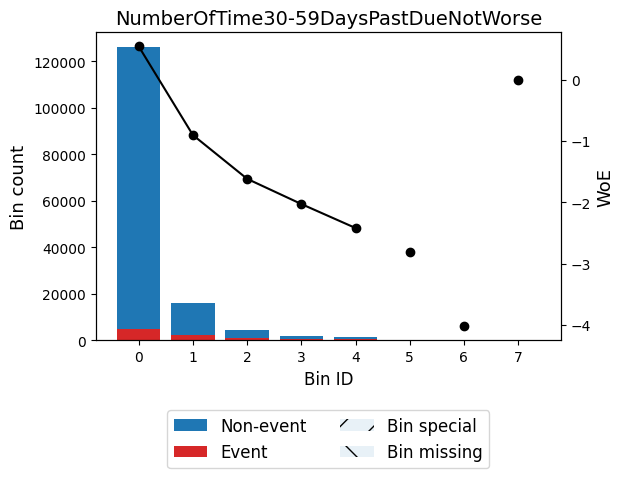

In [72]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTime60-89DaysPastDueNotWorse`

In [73]:
PD60_89_CLIP_UPPER_PCTL = 0.99
PD60_89_CLIP_UPPER = train_raw['NumberOfTime60-89DaysPastDueNotWorse'].quantile(PD60_89_CLIP_UPPER_PCTL)

print(f'{100*PD60_89_CLIP_UPPER_PCTL} процентиль: {PD60_89_CLIP_UPPER}')

99.0 процентиль: 2.0


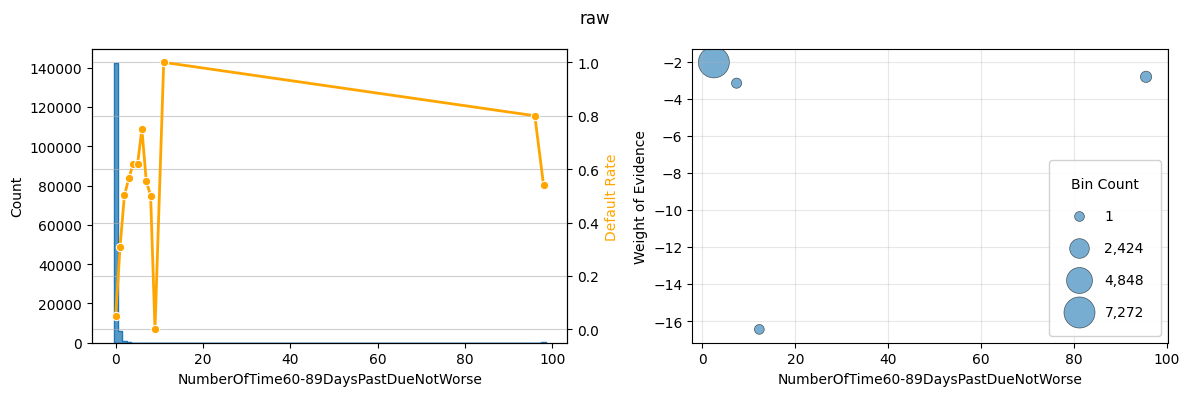

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime60-89DaysPastDueNotWorse', discrete=True,
                      title='', ax=axs[0])
plot_WoE(train_raw, 'NumberOfTime60-89DaysPastDueNotWorse', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### Preprocessing

In [75]:
train_processed['NumberOfTime60-89DaysPastDueNotWorse'] = \
    scale(train_raw['NumberOfTime60-89DaysPastDueNotWorse'].clip(upper=PD60_89_CLIP_UPPER))

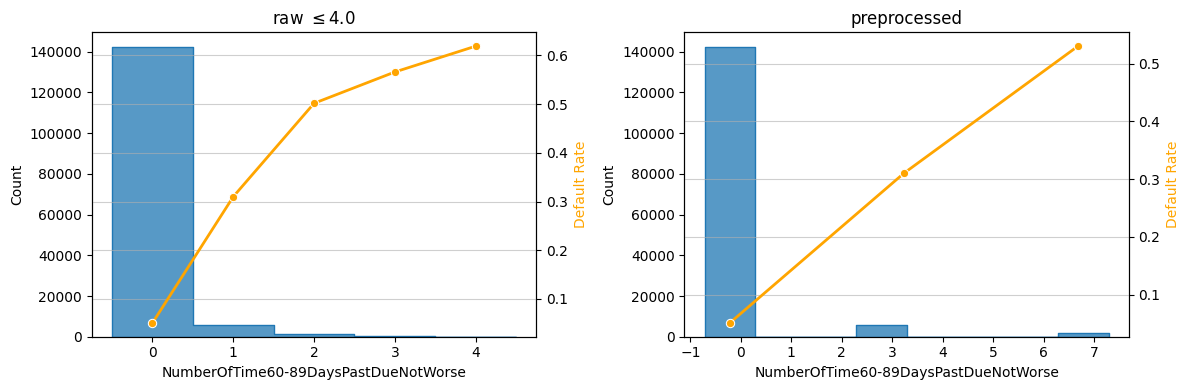

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTime60-89DaysPastDueNotWorse', max_value=2*PD60_89_CLIP_UPPER,
                      title=rf'raw $\leq {2*PD60_89_CLIP_UPPER}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTime60-89DaysPastDueNotWorse', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### WoE Transformation

In [77]:
train_woe['NumberOfTime60-89DaysPastDueNotWorse'], pd60_89_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTime60-89DaysPastDueNotWorse',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    min_prebin_size=0.01,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTime60-89DaysPastDueNotWorse
Binning status: OPTIMAL, N bins: 2
Bins: [0.5 1.5]



In [78]:
binning_table = pd60_89_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",142396,0.949307,135140,7256,0.050956,0.288208,0.069673,0.008679
1,"[0.50, 1.50)",5731,0.038207,3954,1777,0.310068,-1.836474,0.273618,0.030084
2,"[1.50, inf)",1604,0.010693,758,846,0.527431,-2.746111,0.216848,0.020893
3,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
4,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.599275,0.063364


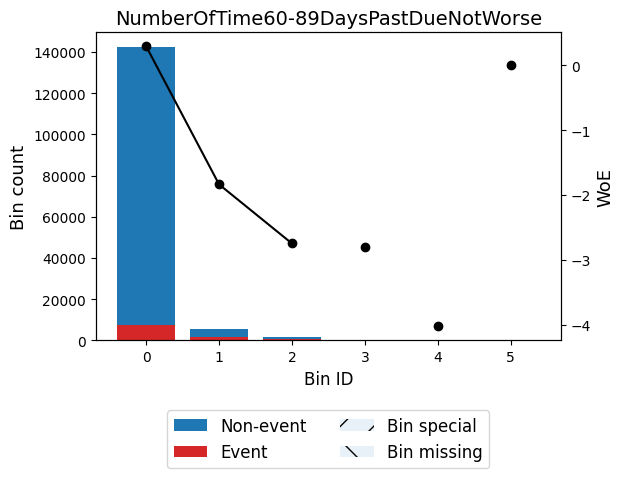

In [79]:
binning_table.plot(figsize=(6, 4))

## `NumberOfTimes90DaysLate`

In [80]:
PD90_CLIP_UPPER_PCTL = 0.99
PD90_CLIP_UPPER = train_raw['NumberOfTimes90DaysLate'].quantile(PD90_CLIP_UPPER_PCTL)

print(f'{100*PD90_CLIP_UPPER_PCTL} процентиль: {PD90_CLIP_UPPER}')

99.0 процентиль: 3.0


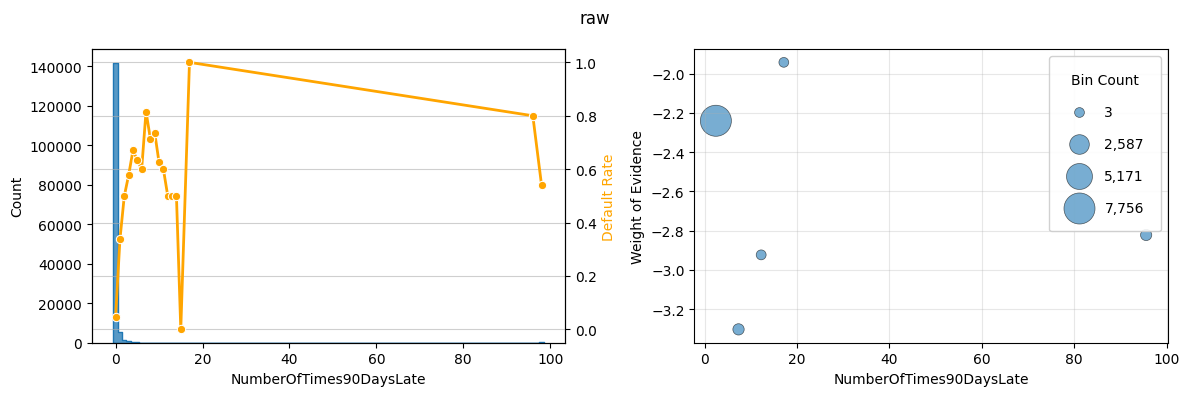

In [81]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTimes90DaysLate', discrete=True,
                      title='', ax=axs[0])
plot_WoE(train_raw, 'NumberOfTimes90DaysLate', ax=axs[1])

fig.suptitle(fr'raw')
plt.tight_layout()

### Preprocessing

In [82]:
train_processed['NumberOfTimes90DaysLate'] = \
    scale(np.log1p(train_raw['NumberOfTimes90DaysLate'].clip(upper=PD90_CLIP_UPPER)))

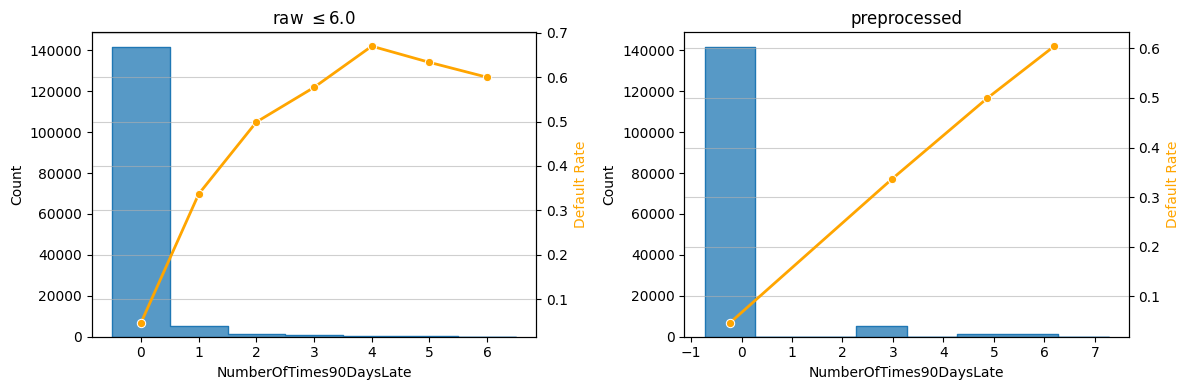

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_feature_analysis(train_raw, 'NumberOfTimes90DaysLate', max_value=2*PD90_CLIP_UPPER,
                      title=rf'raw $\leq {2*PD90_CLIP_UPPER}$', discrete=True, ax=axes[0])
plot_feature_analysis(train_processed, 'NumberOfTimes90DaysLate', discrete=True,
                      title=rf'preprocessed', ax=axes[1])

plt.tight_layout()

### New Features

In [84]:
pd30 = train_raw["NumberOfTime30-59DaysPastDueNotWorse"].clip(upper=PD30_59_CLIP_UPPER)
pd60 = train_raw["NumberOfTime60-89DaysPastDueNotWorse"].clip(upper=PD60_89_CLIP_UPPER)
pd90 = train_raw["NumberOfTimes90DaysLate"].clip(upper=PD90_CLIP_UPPER)

train_processed["has_delinquency"] = ((pd30 + pd60 + pd90) > 0).astype(int)
train_processed["total_delinquencies"] = scale(pd30 + pd60 + pd90)
train_processed["weighted_delinquencies"] = scale(1*pd30 + 2*pd60 + 3*pd90)

### WoE Transformation

In [85]:
train_woe['NumberOfTimes90DaysLate'], pd90_binner = apply_woe_binning(
    df=train_raw,
    feature='NumberOfTimes90DaysLate',
    target=train_raw['SeriousDlqin2yrs'],
    max_n_bins=10,
    min_prebin_size=0.005,
    special_codes={98: 98, 96: 96},
    monotonic_trend='ascending'
)

Feature: NumberOfTimes90DaysLate
Binning status: OPTIMAL, N bins: 3
Bins: [0.5 1.5 2.5]



In [86]:
binning_table = pd90_binner.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",141662,0.944413,135108,6554,0.046265,0.389724,0.121413,0.015081
1,"[0.50, 1.50)",5243,0.034953,3478,1765,0.336639,-1.957968,0.296035,0.032036
2,"[1.50, 2.50)",1555,0.010367,779,776,0.499035,-2.632416,0.189096,0.018548
3,"[2.50, inf)",1271,0.008473,487,784,0.616837,-3.11242,0.232552,0.021115
4,98,264,0.001760,121,143,0.541667,-2.803329,0.037560,0.003586
5,96,5,0.000033,1,4,0.800000,-4.022569,0.001576,0.000123
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,150000,1.000000,139974,10026,0.066840,,0.878232,0.090488


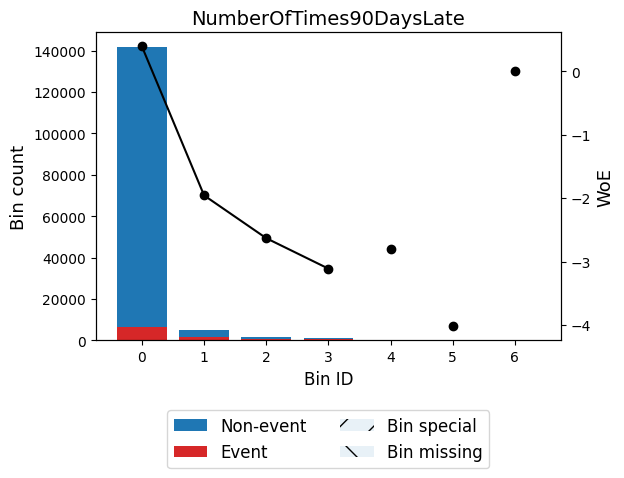

In [87]:
binning_table.plot(figsize=(6, 4))

---

## Resulting DataFrames

In [88]:
# Scale indicators to match the pipeline results
train_processed[['is_young', 'is_senior', 'NumberOfDependents_missing', 'MonthlyIncome_missing', 'MonthlyIncome_clipped', 'MonthlyIncome_zero', 'LowIncome', 'utilization_clipped', 'utilization_99999990', 'DebtRatio_low', 'DebtRatio_clipped', 'DebtRatio_zero', 'DebtRatio_whole', 'NumberOfDependents_missing', 'has_delinquency']] = scale(train_processed[['is_young', 'is_senior', 'NumberOfDependents_missing', 'MonthlyIncome_missing', 'MonthlyIncome_clipped', 'MonthlyIncome_zero', 'LowIncome', 'utilization_clipped', 'utilization_99999990', 'DebtRatio_low', 'DebtRatio_clipped', 'DebtRatio_zero', 'DebtRatio_whole', 'NumberOfDependents_missing', 'has_delinquency']])
train_processed.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,is_young,is_senior,age^2,age^3,MonthlyIncome_missing,MonthlyIncome_clipped,MonthlyIncome_zero,LowIncome,utilization_clipped,utilization_99999990,DebtRatio^2,DebtRatio^3,DebtRatio_low,DebtRatio_clipped,DebtRatio_zero,DebtRatio_whole,NumberOfDependents_missing,NumberOfOpenCreditLinesAndLoans^2,NumberOfOpenCreditLinesAndLoans^3,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines^3,has_delinquency,total_delinquencies,weighted_delinquencies
count,150000.000000,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05,1.500000e+05
mean,0.066840,8.981260e-17,-1.466560e-16,-1.061077e-17,-1.100868e-16,1.234450e-16,-1.811410e-16,2.311632e-17,-4.357995e-17,-1.042129e-18,1.515825e-17,-3.789561e-18,-5.153803e-17,-8.337035e-17,-7.958079e-18,4.054831e-17,4.736952e-19,2.766380e-17,-5.873820e-18,-1.231607e-17,1.477929e-17,1.730408e-16,-4.736952e-20,7.863340e-17,5.456968e-17,1.946887e-17,-6.044350e-17,-1.117921e-17,-2.925541e-16,4.467893e-16,8.905469e-18,4.320100e-17,2.842171e-18,-5.153803e-17,-5.684342e-19
std,0.249746,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,0.000000,-9.133445e-01,-2.127567e+00,-3.687091e-01,-1.896224e+00,-1.270292e+00,-3.507531e+00,-2.310440e-01,-1.006900e+00,-2.177823e-01,-6.802357e-01,-2.499619e-01,-6.893383e-01,-1.575598e+00,-1.200172e+00,-4.971963e-01,-2.936803e-01,-1.049443e-01,-2.952577e-01,-1.504702e-01,-2.709084e-01,-1.353925e+00,-9.466674e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.638985e-01,-2.988412e+00,-2.881055e+00,-6.344194e-01,-4.278152e-01,-5.037784e-01,-3.806136e-01,-3.363348e-01
25%,0.000000,-8.278820e-01,-7.666002e-01,-3.687091e-01,-5.528119e-01,-8.547205e-01,-4.959729e-01,-2.310440e-01,-1.006900e+00,-2.177823e-01,-6.802357e-01,-2.499619e-01,-6.893383e-01,-7.961715e-01,-7.736520e-01,-4.971963e-01,-2.936803e-01,-1.049443e-01,-2.952577e-01,-1.504702e-01,-2.709084e-01,-8.133139e-01,-7.971407e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.638985e-01,-4.984560e-01,-4.853795e-01,-6.344194e-01,-4.278152e-01,-5.037784e-01,-3.806136e-01,-3.363348e-01
50%,0.000000,-4.721729e-01,-1.806820e-02,-3.687091e-01,4.880112e-02,-1.019999e-01,1.855259e-01,-2.310440e-01,7.506605e-03,-2.177823e-01,-6.802357e-01,-2.499619e-01,-6.893383e-01,-1.531448e-01,-2.611490e-01,-4.971963e-01,-2.936803e-01,-1.049443e-01,-2.952577e-01,-1.504702e-01,-2.709084e-01,-1.230185e-01,-3.550026e-01,-8.105785e-01,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.638985e-01,2.018068e-01,2.100955e-01,-3.102487e-01,-3.372201e-01,-5.037784e-01,-3.806136e-01,-3.363348e-01
75%,0.000000,6.863061e-01,7.304638e-01,-3.687091e-01,5.716748e-01,7.137267e-01,6.690570e-01,-2.310440e-01,1.021913e+00,-2.177823e-01,2.539744e-01,-2.499619e-01,1.450666e+00,6.419956e-01,5.212497e-01,-4.971963e-01,-2.936803e-01,-1.049443e-01,-2.952577e-01,-1.504702e-01,-2.709084e-01,6.473674e-01,4.665001e-01,1.233687e+00,-5.108630e-01,-1.679079e-01,-4.992290e-01,-1.638985e-01,6.829960e-01,6.827437e-01,6.622635e-01,2.969452e-01,-5.03778

In [89]:
train_woe.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,0.480237,0.125602,0.263844,0.044402,0.038669,0.029220,0.245961,0.023970,0.174067,0.004667
std,0.249746,1.013906,0.570734,0.666477,0.290067,0.296318,0.242082,0.608987,0.234544,0.507988,0.173935
min,0.000000,-1.396248,-0.618349,-2.418551,-0.596973,-0.499983,-0.727837,-3.112420,-0.253629,-2.746111,-0.469533
25%,0.000000,-0.380305,-0.326797,0.541721,0.000000,-0.229311,0.057593,0.389724,-0.235970,0.288208,-0.102578
50%,0.000000,0.801477,-0.175225,0.541721,0.109178,0.197259,0.132641,0.389724,0.188639,0.288208,0.139828
75%,0.000000,1.395448,0.726566,0.541721,0.109178,0.208442,0.132641,0.389724,0.256641,0.288208,0.139828
max,1.000000,1.395448,1.248390,0.541721,0.692564,0.460761,0.132641,0.389724,0.256641,0.288208,0.139828
